# 01. Data Cleaning & Exploratory Analysis

**Dataset:** London Air Quality (2019 to 2023). Hourly NO2, PM2.5, O3 and SO2 from 5 stations plus weather data.

In this notebook we will:
1. Load raw data from SQLite
2. Inspect missing values and outliers
3. Resample to daily frequency
4. Test for **stationarity** (Augmented Dickey-Fuller test)
5. Check for **white noise**
6. Plot **ACF & PACF**
7. Visualise trends and seasonality

In [23]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from scipy.fft import fft, fftfreq, ifft

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Raw Data from SQLite

In [24]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)

# Load pollution data
pollution = pd.read_sql("SELECT * FROM raw_pollution", conn, parse_dates=["timestamp"])
pollution.set_index("timestamp", inplace=True)

# Load weather data
weather = pd.read_sql("SELECT * FROM raw_weather", conn, parse_dates=["timestamp"])
weather.set_index("timestamp", inplace=True)

conn.close()

# Force numeric types (SQLite sometimes stores NULLs as text)
for col in ["no2", "pm25", "o3", "so2"]:
    pollution[col] = pd.to_numeric(pollution[col], errors="coerce")

# Drop pm25 — entirely empty (0 non-null values in the database)
pollution.drop(columns=["pm25"], inplace=True)

print(f"Pollution: {pollution.shape[0]:,} rows × {pollution.shape[1]} cols")
print(f"Weather:   {weather.shape[0]:,} rows × {weather.shape[1]} cols")
print(f"\nDate range: {pollution.index.min()} → {pollution.index.max()}")
print(f"Sites: {pollution['site_code'].unique().tolist()}")
print(f"\nDtypes:\n{pollution.dtypes}")
print("\n⚠ PM2.5 dropped — column was entirely empty (never ingested)")

Pollution: 219,000 rows × 4 cols
Weather:   43,824 rows × 5 cols

Date range: 2019-01-01 00:00:00 → 2023-12-30 23:00:00
Sites: ['MY1', 'WM0', 'WM6', 'BL0', 'CD9']

Dtypes:
site_code     object
no2          float64
o3           float64
so2          float64
dtype: object

⚠ PM2.5 dropped — column was entirely empty (never ingested)


In [25]:
print("=== Pollution (first 5 rows) ===")
display(pollution.head())
print("\n=== Weather (first 5 rows) ===")
display(weather.head())

=== Pollution (first 5 rows) ===


,site_code,no2,o3,so2
timestamp,,,,
2019-01-01 00:00:00,MY1,52.4,27.5,1.9
2019-01-01 01:00:00,MY1,46.7,32.3,2.0
2019-01-01 02:00:00,MY1,43.6,38.6,1.9
2019-01-01 03:00:00,MY1,25.6,48.5,1.3
2019-01-01 04:00:00,MY1,40.2,34.9,1.6



=== Weather (first 5 rows) ===


,temperature,windspeed,winddirection,precipitation,humidity
timestamp,,,,,
2019-01-01 00:00:00,6.8,10.3,258.0,0.0,93.0
2019-01-01 01:00:00,7.0,11.7,259.0,0.0,92.0
2019-01-01 02:00:00,6.6,11.4,257.0,0.0,93.0
2019-01-01 03:00:00,5.7,10.5,262.0,0.0,94.0
2019-01-01 04:00:00,5.0,11.6,263.0,0.0,95.0


## 2. Missing Values & Data Quality

In [26]:
# Missing values per column (pollution)
poll_missing = pollution.isnull().sum()
poll_pct = (poll_missing / len(pollution) * 100).round(2)

missing_df = pd.DataFrame({"missing": poll_missing, "pct (%)": poll_pct})
print("=== Pollution — Missing Values ===")
display(missing_df)

# Missing values per column (weather)
weather_missing = weather.isnull().sum()
weather_pct = (weather_missing / len(weather) * 100).round(2)

missing_w = pd.DataFrame({"missing": weather_missing, "pct (%)": weather_pct})
print("\n=== Weather — Missing Values ===")
display(missing_w)

=== Pollution — Missing Values ===


,missing,pct (%)
site_code,0,0.00
no2,48999,22.37
o3,137648,62.85
so2,143211,65.39



=== Weather — Missing Values ===


,missing,pct (%)
temperature,0,0.0
windspeed,0,0.0
winddirection,0,0.0
precipitation,0,0.0
humidity,0,0.0


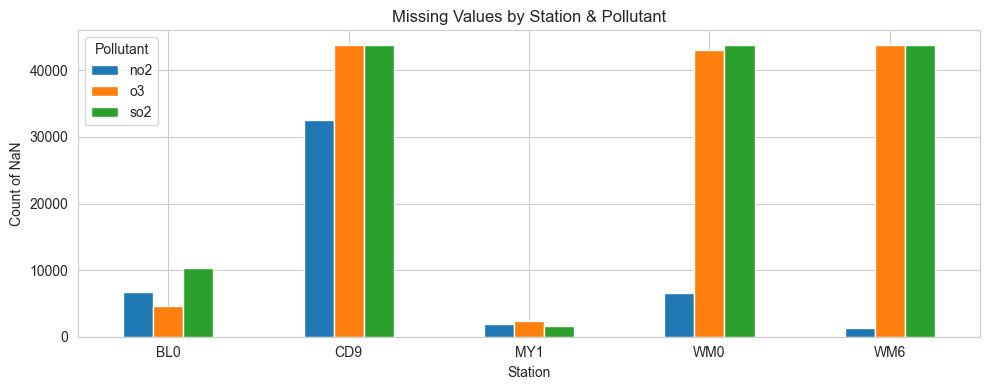

In [27]:
# Missing values broken down by station
pollutants = ["no2", "o3", "so2"]
missing_by_site = pollution.groupby("site_code")[pollutants].apply(lambda g: g.isnull().sum())

fig, ax = plt.subplots(figsize=(10, 4))
missing_by_site.plot(kind="bar", ax=ax)
ax.set_title("Missing Values by Station & Pollutant")
ax.set_ylabel("Count of NaN")
ax.set_xlabel("Station")
plt.xticks(rotation=0)
plt.legend(title="Pollutant")
plt.tight_layout()
plt.show()

## 3. Focus on a Single Station (MY1) & Clean

We pick **MY1 (Marylebone Road)**, one of London's busiest roadside monitors, for our time series analysis. We will:
- Forward-fill short gaps (≤ 3 hours)
- Drop remaining NaNs

In [28]:
# Filter for MY1 station and drop the site_code column
my1 = pollution[pollution["site_code"] == "MY1"][pollutants].copy()
my1 = my1.sort_index()

# Ensure complete hourly index (fill any gaps in timestamps)
full_idx = pd.date_range(my1.index.min(), my1.index.max(), freq="h")
my1 = my1.reindex(full_idx)
my1.index.name = "timestamp"

print(f"Shape after reindex: {my1.shape}")
print(f"Missing before cleaning:\n{my1.isnull().sum()}\n")

# Forward-fill gaps up to 3 hours, then drop remaining NaNs
my1 = my1.ffill(limit=3)
dropped = my1.isnull().any(axis=1).sum()
my1 = my1.dropna()

print(f"Rows dropped after ffill(3): {dropped}")
print(f"Final shape: {my1.shape}")
print(f"Date range: {my1.index.min()} → {my1.index.max()}")
my1.head()

Shape after reindex: (43800, 3)
Missing before cleaning:
no2    1863
o3     2426
so2    1547
dtype: int64

Rows dropped after ffill(3): 2832
Final shape: (40968, 3)
Date range: 2019-01-01 00:00:00 → 2023-12-30 23:00:00


,no2,o3,so2
timestamp,,,
2019-01-01 00:00:00,52.4,27.5,1.9
2019-01-01 01:00:00,46.7,32.3,2.0
2019-01-01 02:00:00,43.6,38.6,1.9
2019-01-01 03:00:00,25.6,48.5,1.3
2019-01-01 04:00:00,40.2,34.9,1.6


,no2,o3,so2
count,40968.00,40968.00,40968.00
mean,46.70,28.04,2.39
std,24.87,19.80,2.41
min,0.80,-0.20,-5.60
25%,27.30,12.20,0.80
50%,43.60,24.70,1.60
75%,62.30,40.50,3.20
max,197.90,156.50,26.10


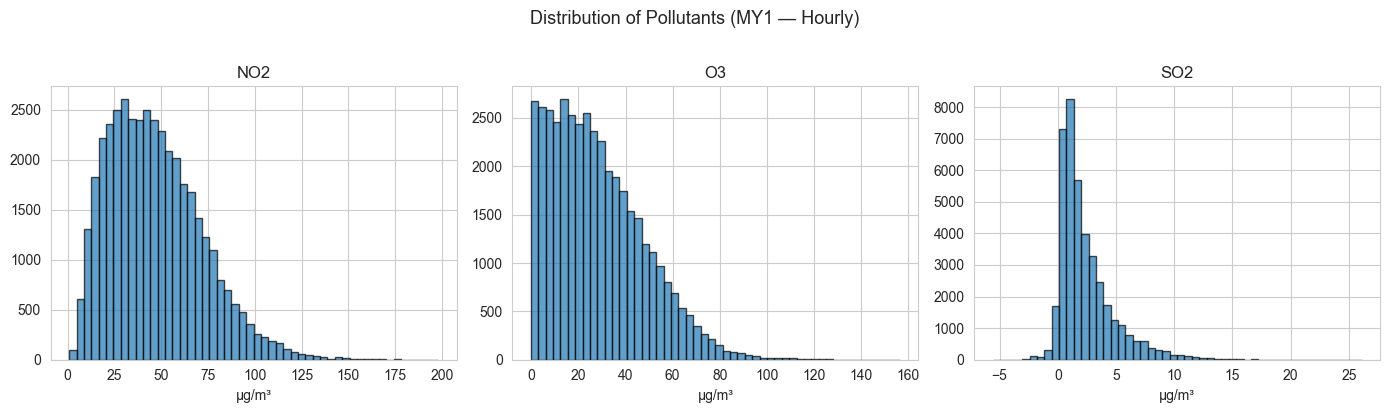

In [29]:
# Summary statistics
display(my1.describe().round(2))

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, pollutants):
    my1[col].hist(bins=50, ax=ax, edgecolor="black", alpha=0.7)
    ax.set_title(col.upper())
    ax.set_xlabel("µg/m³")
fig.suptitle("Distribution of Pollutants (MY1 — Hourly)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Resample to Daily Frequency

Hourly data is noisy for modelling. We aggregate to **daily means** which smooths out intra-day variation while preserving trends and seasonality.

Daily shape: (1752, 3)
Date range: 2019-01-01 → 2023-12-30


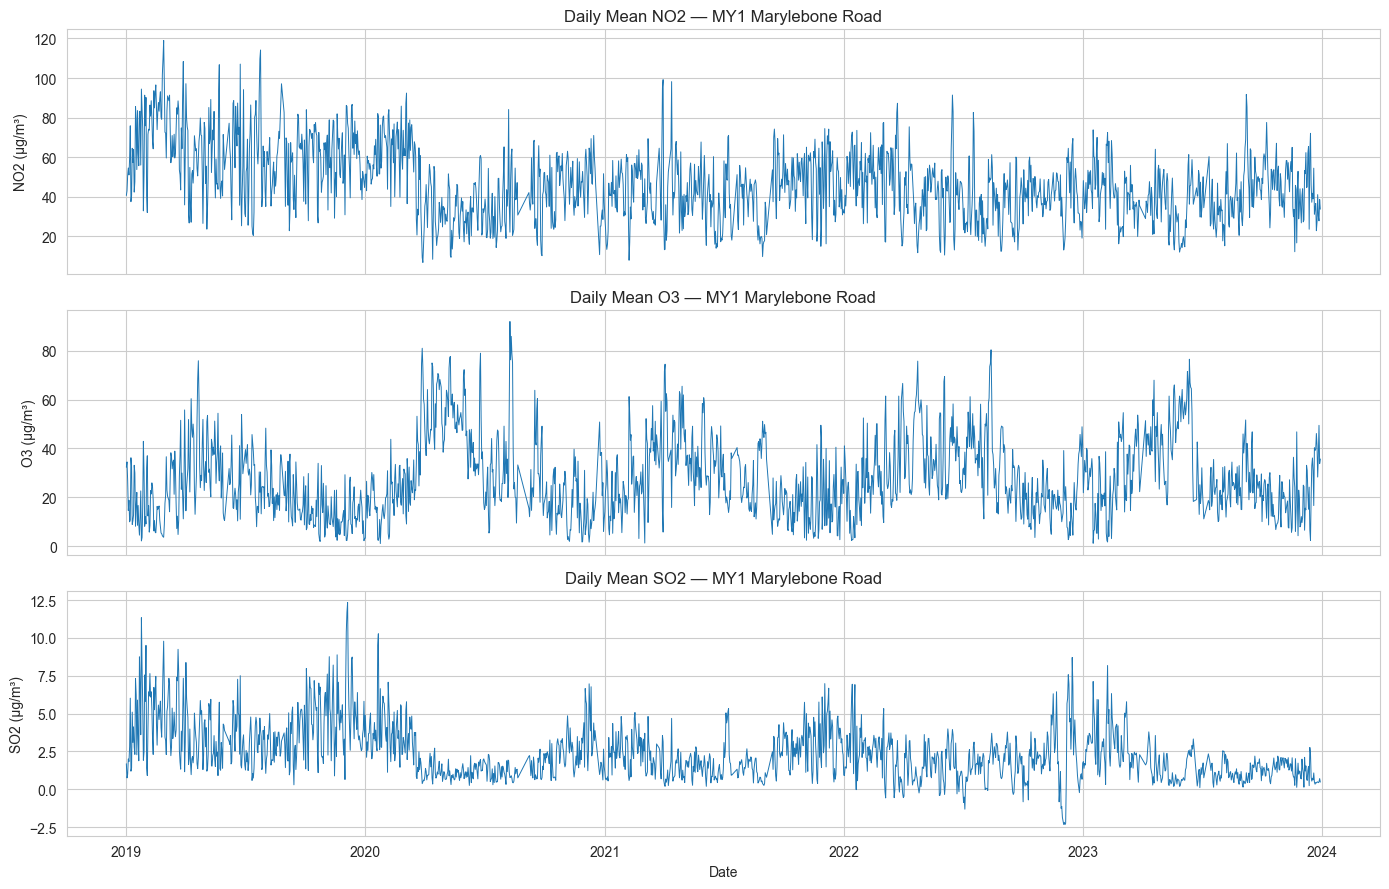

In [30]:
# Resample to daily mean
daily = my1.resample("D").mean()
daily = daily.dropna()

print(f"Daily shape: {daily.shape}")
print(f"Date range: {daily.index.min().date()} → {daily.index.max().date()}")

# Plot all pollutants over time
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, col in zip(axes, pollutants):
    ax.plot(daily.index, daily[col], linewidth=0.7)
    ax.set_ylabel(f"{col.upper()} (µg/m³)")
    ax.set_title(f"Daily Mean {col.upper()} — MY1 Marylebone Road")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 5. Outlier Detection

Box plots to identify extreme values. We keep outliers for now as they may represent real pollution spikes (e.g. bonfires or traffic incidents).

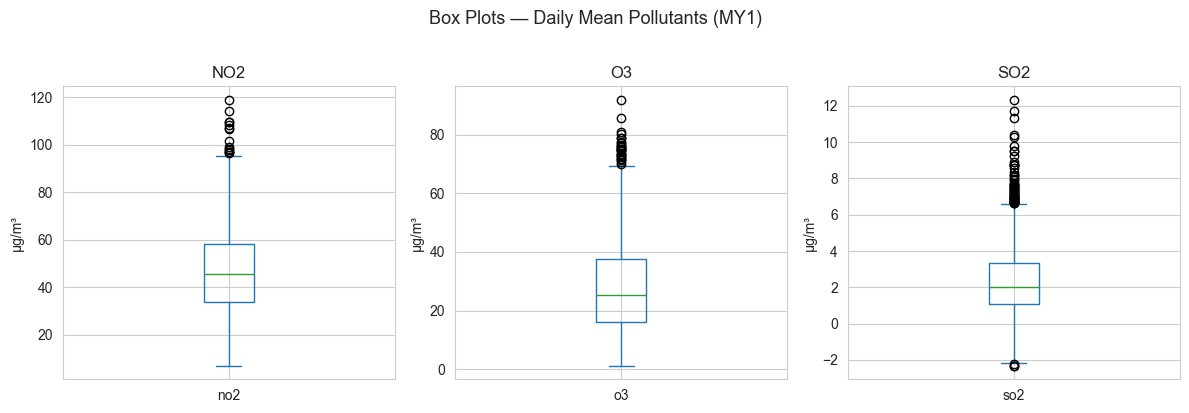

Outliers (IQR × 1.5):
  NO2  : 14 days
  O3   : 27 days
  SO2  : 62 days


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, pollutants):
    daily[col].plot.box(ax=ax)
    ax.set_title(col.upper())
    ax.set_ylabel("µg/m³")
fig.suptitle("Box Plots — Daily Mean Pollutants (MY1)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Count outliers using IQR method
print("Outliers (IQR × 1.5):")
for col in pollutants:
    q1, q3 = daily[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((daily[col] < q1 - 1.5 * iqr) | (daily[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col.upper():5s}: {n_outliers} days")

## 6. Stationarity: Augmented Dickey-Fuller Test

A time series is **stationary** if its statistical properties (mean and variance) do not change over time. Most models (AR, MA, ARMA and ARIMA) assume stationarity.

**ADF Test:**
- H₀: The series has a **unit root** (non-stationary)
- H₁: The series is **stationary**
- If p-value < 0.05 → reject H₀ → series is stationary

In [32]:
def adf_test(series, name=""):
    """Run ADF test and print results."""
    result = adfuller(series, autolag="AIC")
    print(f"ADF Test: {name}")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Lags Used      : {result[2]}")
    print(f"  Observations   : {result[3]}")
    for key, val in result[4].items():
        print(f"  Critical {key:4s}  : {val:.4f}")
    verdict = "✓ Stationary" if result[1] < 0.05 else "✗ Non-stationary"
    print(f"  → {verdict}\n")
    return result[1]

print("="*50)
print("ADF TEST ON DAILY MEAN (LEVEL)")
print("="*50 + "\n")

for col in pollutants:
    adf_test(daily[col], name=col.upper())

ADF TEST ON DAILY MEAN (LEVEL)

ADF Test: NO2
  Test Statistic : -3.7082
  p-value        : 0.004000
  Lags Used      : 25
  Observations   : 1726
  Critical 1%    : -3.4341
  Critical 5%    : -2.8632
  Critical 10%   : -2.5677
  → ✓ Stationary

ADF Test: O3
  Test Statistic : -3.7633
  p-value        : 0.003306
  Lags Used      : 23
  Observations   : 1728
  Critical 1%    : -3.4341
  Critical 5%    : -2.8632
  Critical 10%   : -2.5677
  → ✓ Stationary

ADF Test: SO2
  Test Statistic : -3.3384
  p-value        : 0.013247
  Lags Used      : 25
  Observations   : 1726
  Critical 1%    : -3.4341
  Critical 5%    : -2.8632
  Critical 10%   : -2.5677
  → ✓ Stationary



ADF TEST ON FIRST-DIFFERENCED SERIES

ADF Test: ΔNO2
  Test Statistic : -14.1580
  p-value        : 0.000000
  Lags Used      : 25
  Observations   : 1725
  Critical 1%    : -3.4341
  Critical 5%    : -2.8632
  Critical 10%   : -2.5677
  → ✓ Stationary

ADF Test: ΔO3
  Test Statistic : -13.5243
  p-value        : 0.000000
  Lags Used      : 22
  Observations   : 1728
  Critical 1%    : -3.4341
  Critical 5%    : -2.8632
  Critical 10%   : -2.5677
  → ✓ Stationary

ADF Test: ΔSO2
  Test Statistic : -14.8546
  p-value        : 0.000000
  Lags Used      : 25
  Observations   : 1725
  Critical 1%    : -3.4341
  Critical 5%    : -2.8632
  Critical 10%   : -2.5677
  → ✓ Stationary



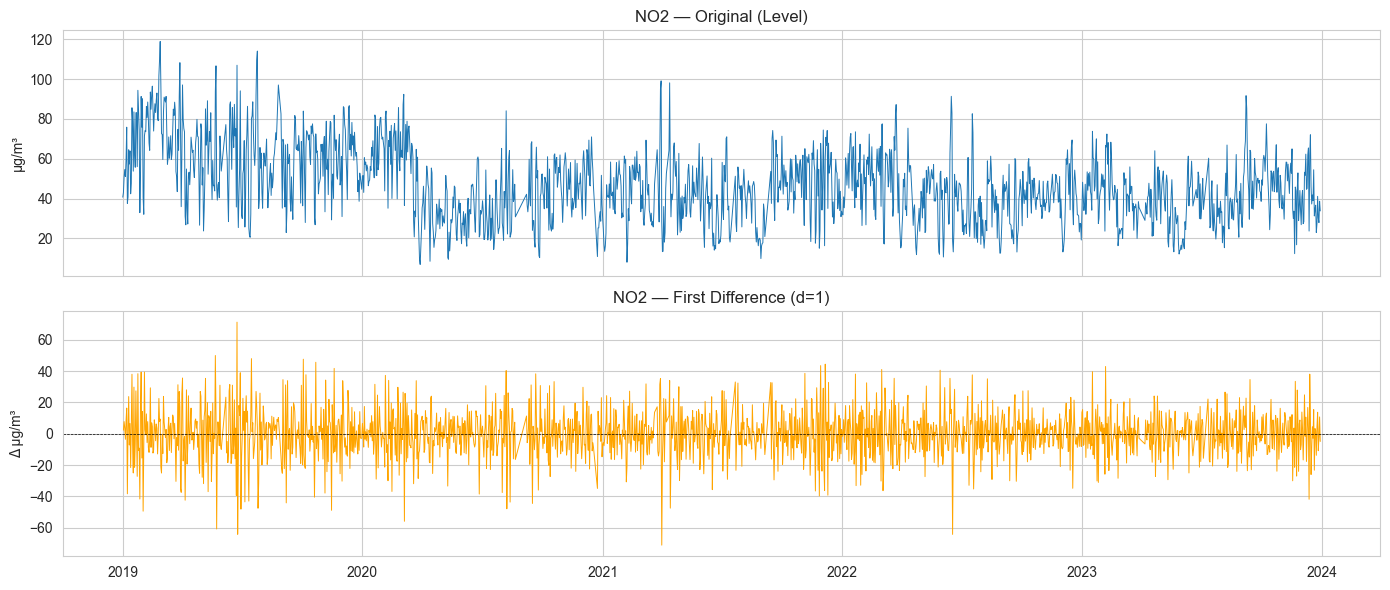

In [33]:
# First differencing: y'(t) = y(t) - y(t-1)
daily_diff = daily.diff().dropna()

print("="*50)
print("ADF TEST ON FIRST-DIFFERENCED SERIES")
print("="*50 + "\n")

for col in pollutants:
    adf_test(daily_diff[col], name=f"Δ{col.upper()}")

# Plot original vs differenced for NO2
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(daily["no2"], linewidth=0.7)
axes[0].set_title("NO2 — Original (Level)")
axes[0].set_ylabel("µg/m³")

axes[1].plot(daily_diff["no2"], linewidth=0.7, color="orange")
axes[1].set_title("NO2 — First Difference (d=1)")
axes[1].set_ylabel("Δ µg/m³")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

## 7. White Noise Test (Ljung-Box)

**White noise** = purely random with no autocorrelation. If our series is white noise, there's nothing to model.

- H₀: The series is white noise (no autocorrelation)
- H₁: The series has significant autocorrelation
- If p-value < 0.05 → reject H₀ → series is **not** white noise → we can model it

In [34]:
print("Ljung-Box Test (lag=20) on Daily Levels:\n")
for col in pollutants:
    lb = acorr_ljungbox(daily[col], lags=[20], return_df=True)
    p = lb["lb_pvalue"].values[0]
    verdict = "✗ White noise" if p > 0.05 else "✓ NOT white noise (autocorrelation exists)"
    print(f"  {col.upper():5s}: Q={lb['lb_stat'].values[0]:.2f}, p={p:.6f}  → {verdict}")

Ljung-Box Test (lag=20) on Daily Levels:

  NO2  : Q=4293.66, p=0.000000  → ✓ NOT white noise (autocorrelation exists)
  O3   : Q=7114.34, p=0.000000  → ✓ NOT white noise (autocorrelation exists)
  SO2  : Q=5580.00, p=0.000000  → ✓ NOT white noise (autocorrelation exists)


## 8. Autocorrelation (ACF) & Partial Autocorrelation (PACF)

- **ACF** is the correlation of the series with its own lagged values. Helps identify MA(q) order.
- **PACF** is the correlation after removing intermediate lag effects. Helps identify AR(p) order.

| Pattern | ACF | PACF | Suggests |
|---------|-----|------|----------|
| AR(p)   | Tails off | Cuts off at lag p | Autoregressive |
| MA(q)   | Cuts off at lag q | Tails off | Moving Average |
| ARMA    | Tails off | Tails off | Mixed model |

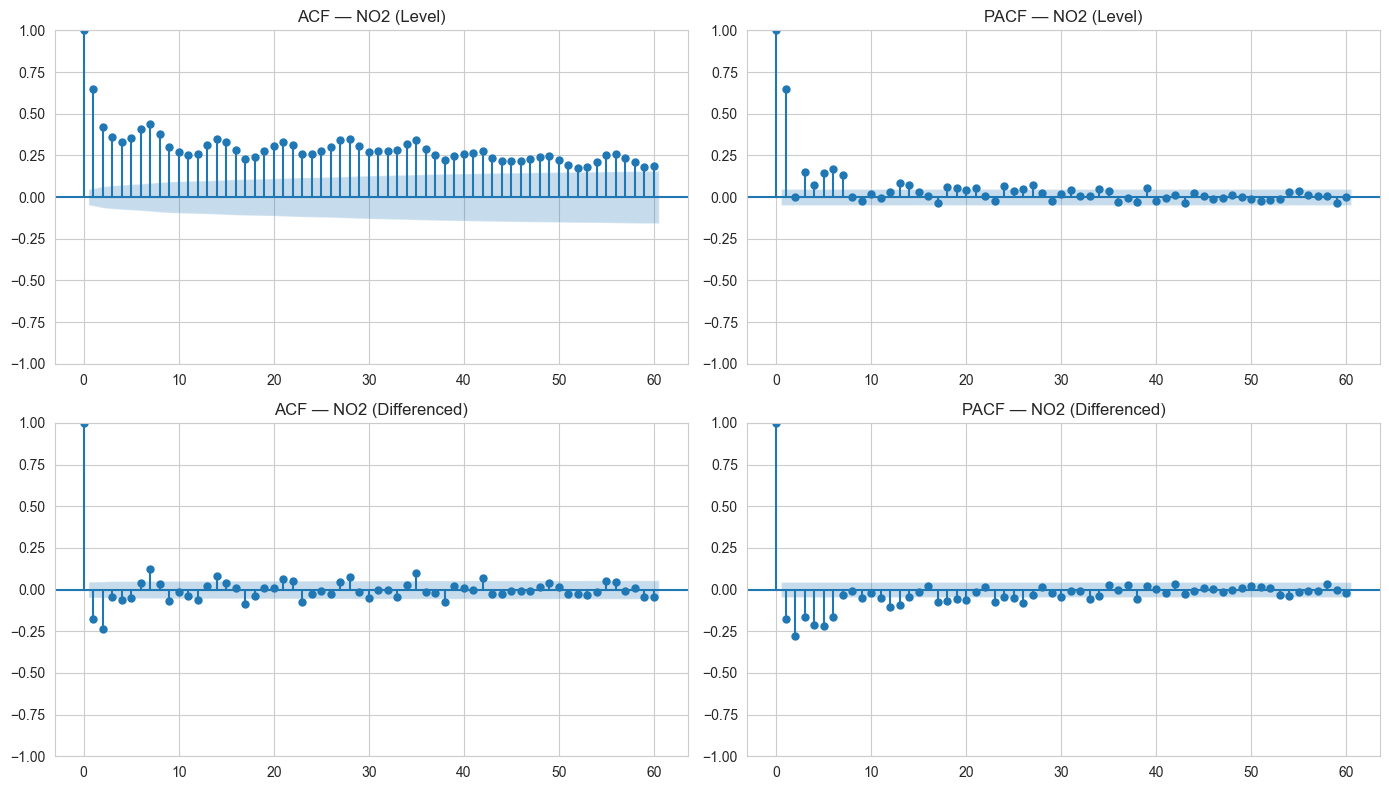

In [35]:
# ACF & PACF for NO2 (daily level)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(daily["no2"], lags=60, ax=axes[0, 0], title="ACF — NO2 (Level)")
plot_pacf(daily["no2"], lags=60, ax=axes[0, 1], title="PACF — NO2 (Level)")

# Also on differenced series
plot_acf(daily_diff["no2"], lags=60, ax=axes[1, 0], title="ACF — NO2 (Differenced)")
plot_pacf(daily_diff["no2"], lags=60, ax=axes[1, 1], title="PACF — NO2 (Differenced)")

plt.tight_layout()
plt.show()

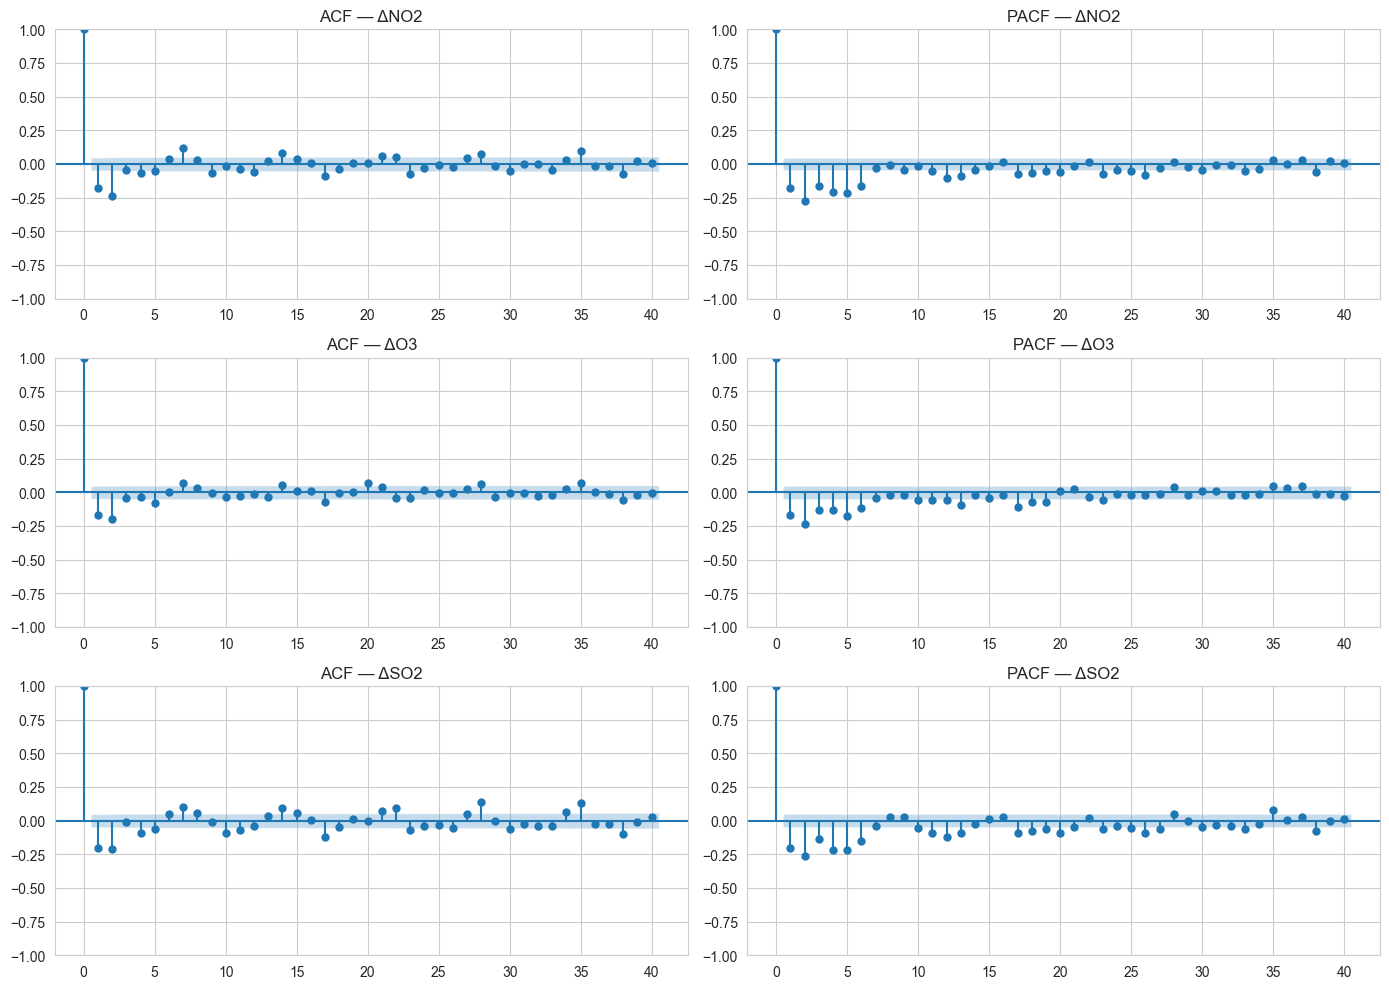

In [36]:
# ACF & PACF for all 3 pollutants (differenced)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(pollutants):
    plot_acf(daily_diff[col], lags=40, ax=axes[i, 0], title=f"ACF — Δ{col.upper()}")
    plot_pacf(daily_diff[col], lags=40, ax=axes[i, 1], title=f"PACF — Δ{col.upper()}")

plt.tight_layout()
plt.show()

## 9. Trend & Seasonality Decomposition

Decompose each series into **Trend**, **Seasonal** and **Residual** components. This helps us:
- Confirm seasonality exists (important for SARIMA later)
- Understand the period (weekly = 7, yearly = 365)

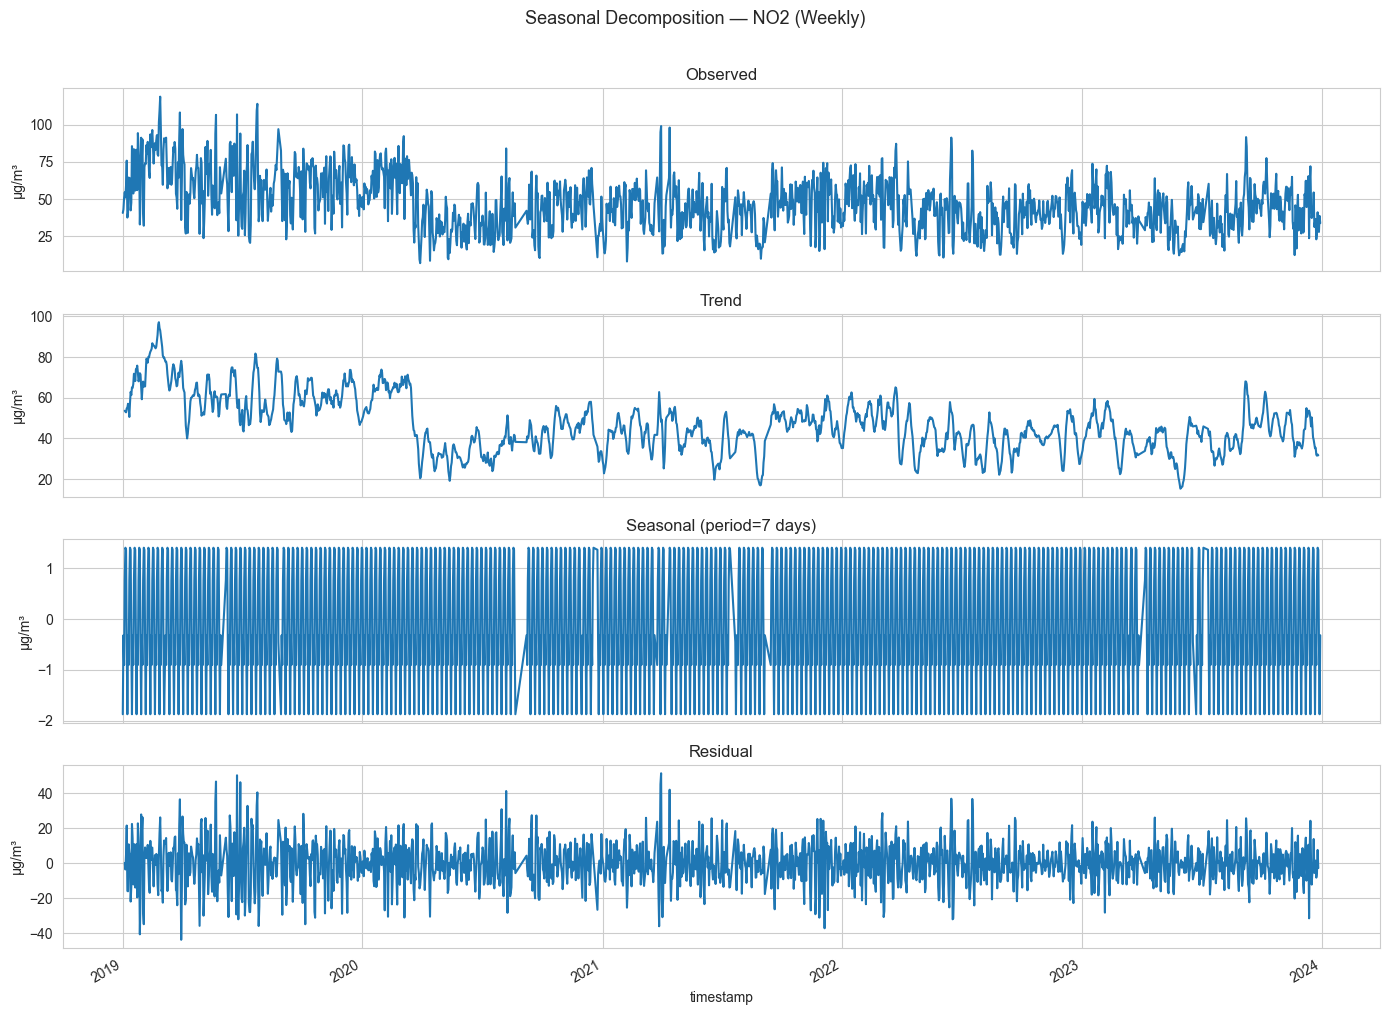

In [37]:
# Decompose NO2 with weekly seasonality (period=7)
decomp = seasonal_decompose(daily["no2"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonal (period=7 days)")
decomp.resid.plot(ax=axes[3], title="Residual")

for ax in axes:
    ax.set_ylabel("µg/m³")
fig.suptitle("Seasonal Decomposition — NO2 (Weekly)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 10. Rolling Mean & Variance (Visual Stationarity Check)

If the rolling mean and variance are roughly constant over time, the series is likely stationary.

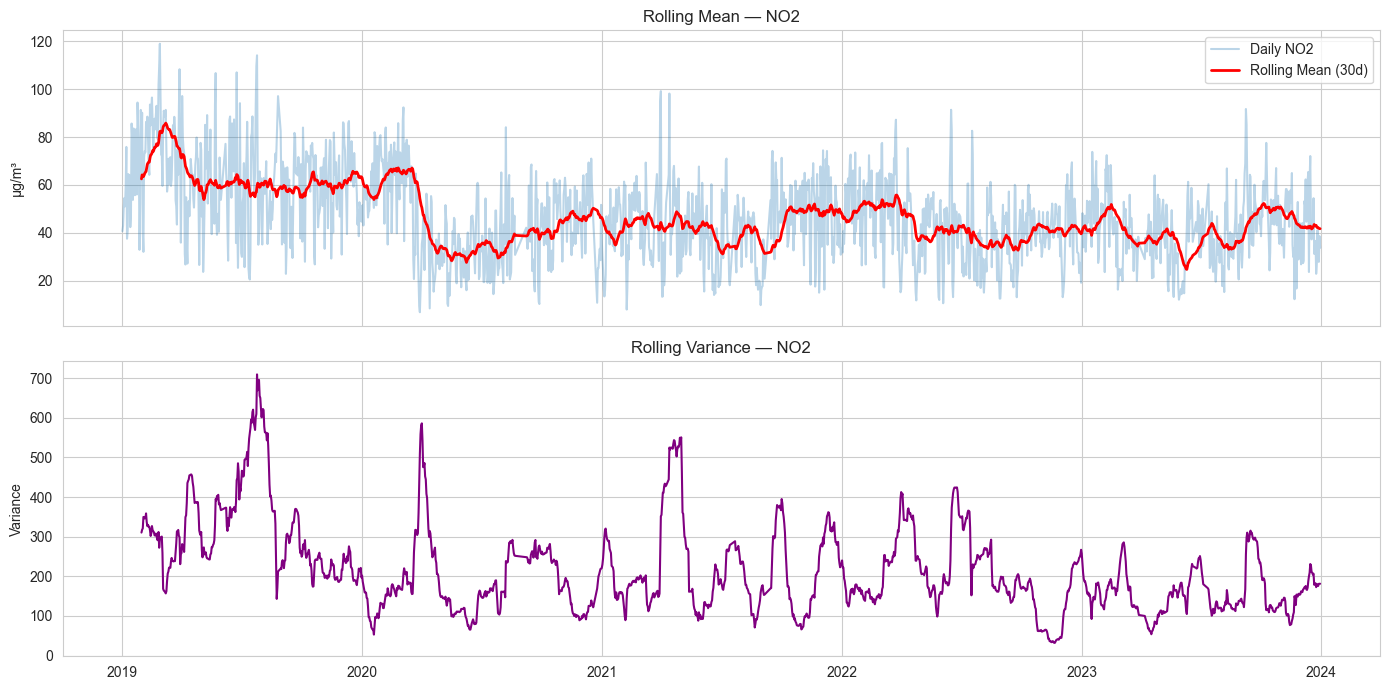

In [38]:
window = 30  # 30-day rolling window

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Rolling mean
axes[0].plot(daily["no2"], alpha=0.3, label="Daily NO2")
axes[0].plot(daily["no2"].rolling(window).mean(), color="red", linewidth=2, label=f"Rolling Mean ({window}d)")
axes[0].set_title("Rolling Mean — NO2")
axes[0].set_ylabel("µg/m³")
axes[0].legend()

# Rolling variance
axes[1].plot(daily["no2"].rolling(window).var(), color="purple", linewidth=1.5)
axes[1].set_title("Rolling Variance — NO2")
axes[1].set_ylabel("Variance")

plt.tight_layout()
plt.show()

## 11. Merge Weather Data & Correlation Heatmap

Understanding pollution–weather relationships will be useful for the **VAR model** later.

Merged shape: (1752, 8)


,no2,o3,so2,temperature,windspeed,winddirection,precipitation,humidity
timestamp,,,,,,,,
2019-01-01,40.679167,32.333333,1.691667,6.837500,12.716667,231.166667,0.008333,87.000000
2019-01-02,43.000000,34.504167,0.754167,3.683333,8.920833,348.666667,0.000000,81.041667
2019-01-03,50.812500,26.829167,1.000000,1.950000,5.970833,169.208333,0.000000,86.833333
2019-01-04,54.554167,14.608333,2.008333,-0.533333,6.533333,261.458333,0.000000,90.000000
2019-01-05,51.041667,18.820833,1.837500,1.908333,8.658333,286.208333,0.000000,88.875000


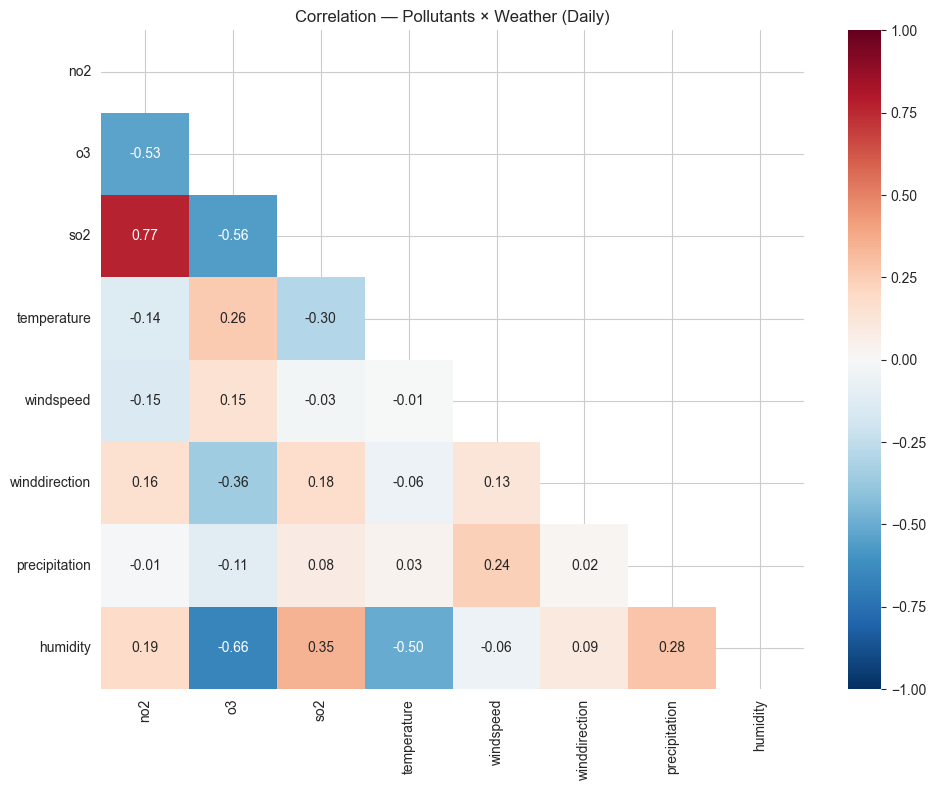

In [39]:
# Resample weather to daily
weather_daily = weather.resample("D").mean()

# Merge pollution + weather on date
merged = daily.join(weather_daily, how="inner")
print(f"Merged shape: {merged.shape}")
display(merged.head())

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = merged.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation — Pollutants × Weather (Daily)")
plt.tight_layout()
plt.show()

## 12. Fourier Analysis: Frequency Domain

The **Fourier Transform** decomposes a time series into a sum of sinusoidal waves (sines & cosines) at different frequencies. This reveals the **dominant cycles** hidden in the data.

$$X(f) = \sum_{t=0}^{N-1} x(t) \cdot e^{-i 2\pi f t / N}$$

- **High amplitude at a frequency** → strong periodic component at that cycle length
- Converts from **time domain** (what we've seen so far) to **frequency domain**
- Peaks in the power spectrum tell us exactly which periodicities matter (7-day? 365-day?)

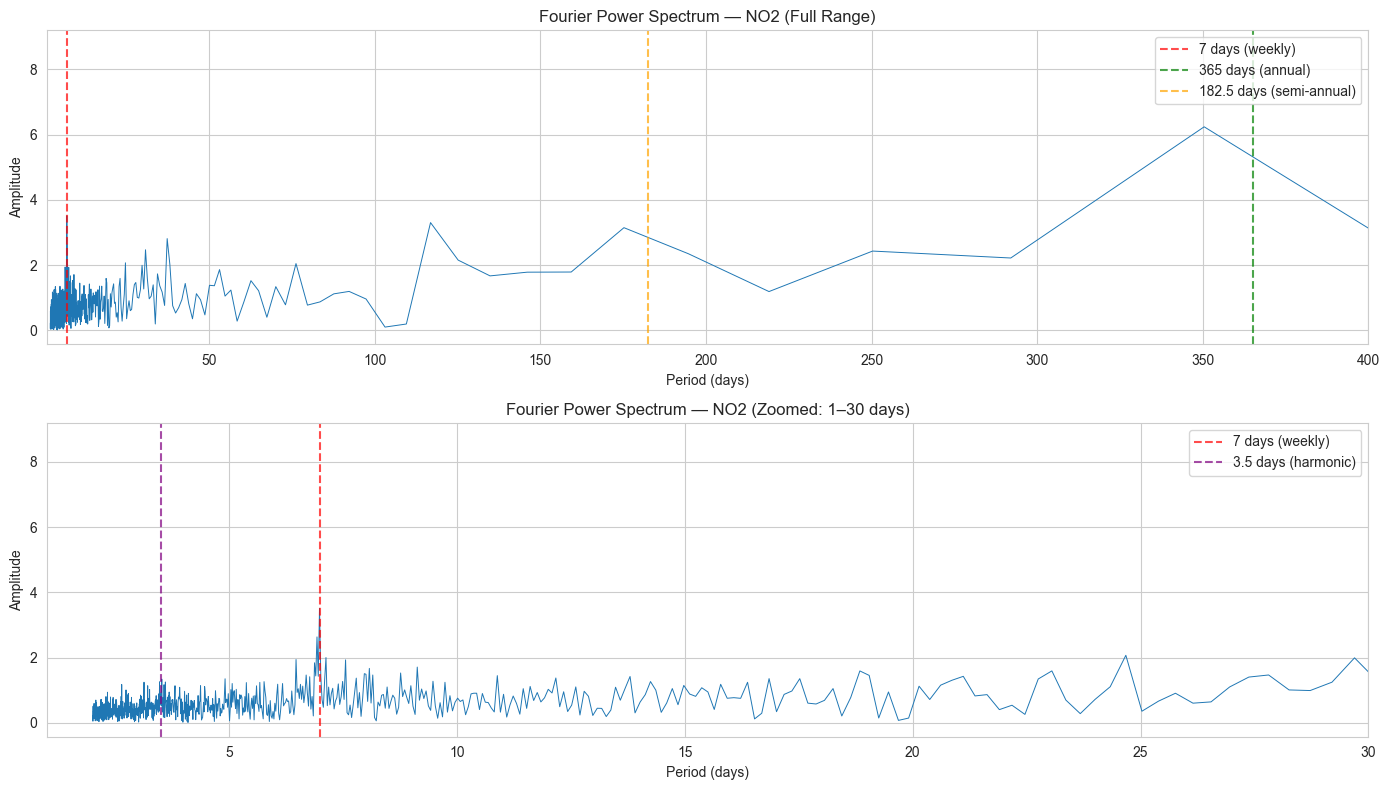

Top 10 Dominant Periods (NO2):
Rank   Period (days)    Amplitude   
----------------------------------
1      876.0            8.76        
2      1752.0           7.92        
3      350.4            6.24        
4      7.0              3.51        
5      116.8            3.30        
6      175.2            3.15        
7      37.3             2.81        
8      6.9              2.64        
9      30.7             2.47        
10     250.3            2.43        


In [40]:
def fourier_analysis(series, sampling_rate=1, name=""):
    """
    Compute FFT and return frequencies, periods, and power spectrum.
    sampling_rate: samples per day (1 for daily data)
    """
    N = len(series)
    # Remove mean (detrend) to focus on oscillations
    y = series.values - series.mean()
    
    # Compute FFT
    yf = fft(y)
    xf = fftfreq(N, d=1/sampling_rate)  # frequencies in cycles per day
    
    # Power spectrum (only positive frequencies)
    positive = xf > 0
    freqs = xf[positive]
    power = 2.0 / N * np.abs(yf[positive])
    periods = 1.0 / freqs  # convert frequency to period (days)
    
    return freqs, periods, power

# Compute FFT for NO2
freqs, periods, power = fourier_analysis(daily["no2"], sampling_rate=1, name="NO2")

# Plot power spectrum vs period
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full spectrum
axes[0].plot(periods, power, linewidth=0.7)
axes[0].set_xlim(1, 400)
axes[0].set_xlabel("Period (days)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Fourier Power Spectrum — NO2 (Full Range)")
axes[0].axvline(7, color="red", linestyle="--", alpha=0.7, label="7 days (weekly)")
axes[0].axvline(365, color="green", linestyle="--", alpha=0.7, label="365 days (annual)")
axes[0].axvline(182.5, color="orange", linestyle="--", alpha=0.7, label="182.5 days (semi-annual)")
axes[0].legend()

# Zoomed in: 1–30 days
axes[1].plot(periods, power, linewidth=0.7)
axes[1].set_xlim(1, 30)
axes[1].set_xlabel("Period (days)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Fourier Power Spectrum — NO2 (Zoomed: 1–30 days)")
axes[1].axvline(7, color="red", linestyle="--", alpha=0.7, label="7 days (weekly)")
axes[1].axvline(3.5, color="purple", linestyle="--", alpha=0.7, label="3.5 days (harmonic)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print top 10 dominant periods
top_idx = np.argsort(power)[::-1][:10]
print("Top 10 Dominant Periods (NO2):")
print(f"{'Rank':<6} {'Period (days)':<16} {'Amplitude':<12}")
print("-" * 34)
for rank, idx in enumerate(top_idx, 1):
    print(f"{rank:<6} {periods[idx]:<16.1f} {power[idx]:<12.2f}")

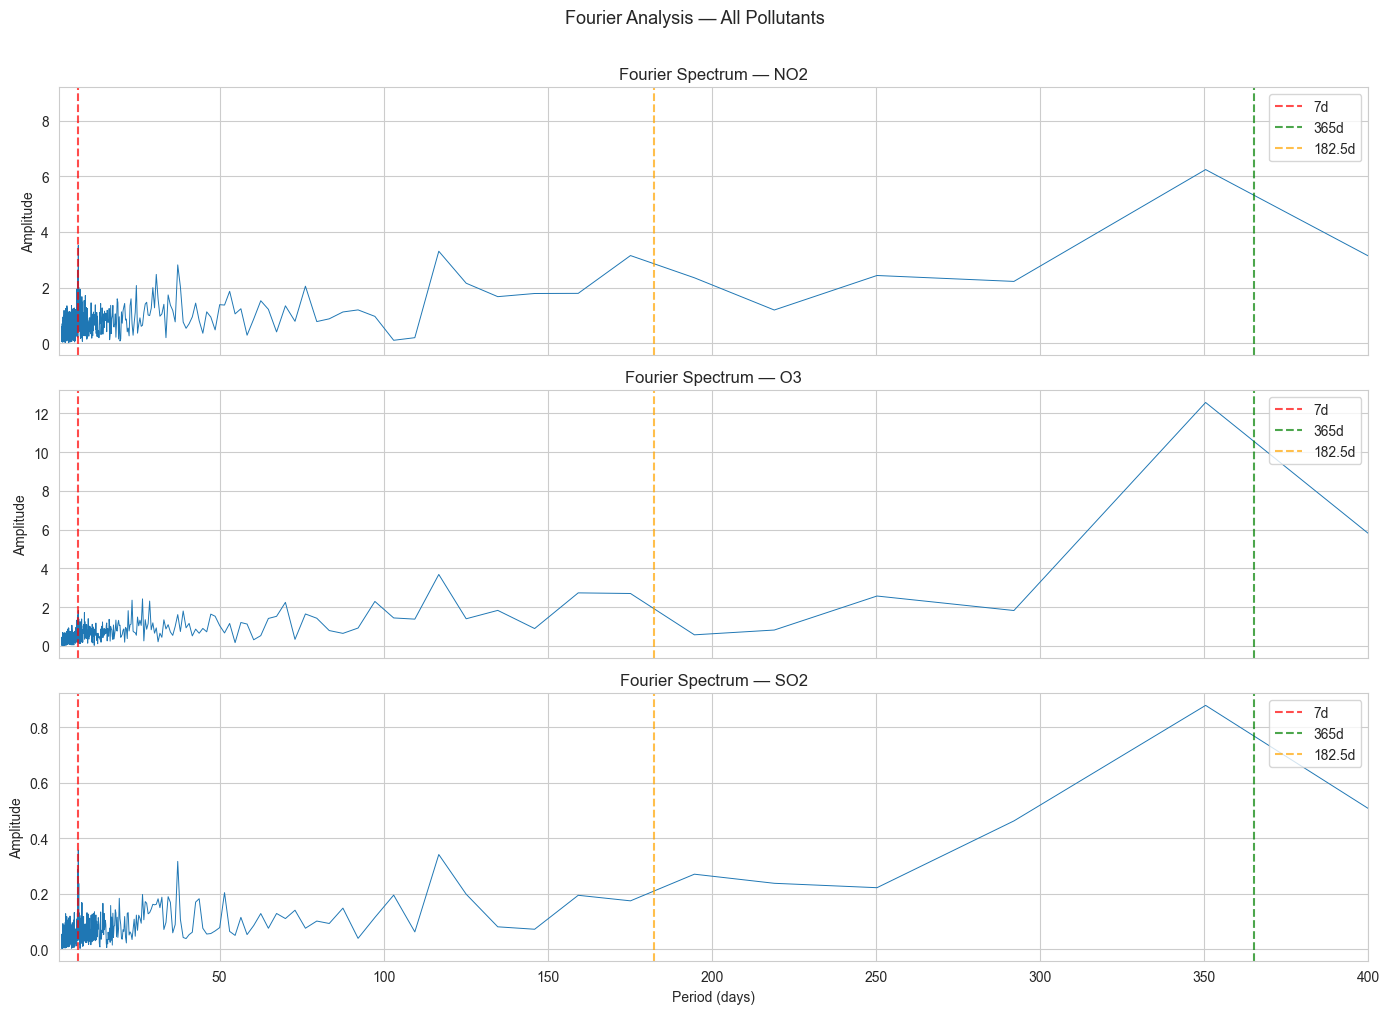

In [41]:
# Fourier spectra for all 3 pollutants
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, pollutants):
    f, p, pw = fourier_analysis(daily[col])
    ax.plot(p, pw, linewidth=0.7)
    ax.set_xlim(1, 400)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Fourier Spectrum — {col.upper()}")
    ax.axvline(7, color="red", linestyle="--", alpha=0.7, label="7d")
    ax.axvline(365, color="green", linestyle="--", alpha=0.7, label="365d")
    ax.axvline(182.5, color="orange", linestyle="--", alpha=0.7, label="182.5d")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Period (days)")
fig.suptitle("Fourier Analysis — All Pollutants", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Fourier Reconstruction: Approximating with Top Frequencies

We can **reconstruct** the signal using only the most dominant Fourier components. This shows how much of the variation is explained by just a few periodic cycles.

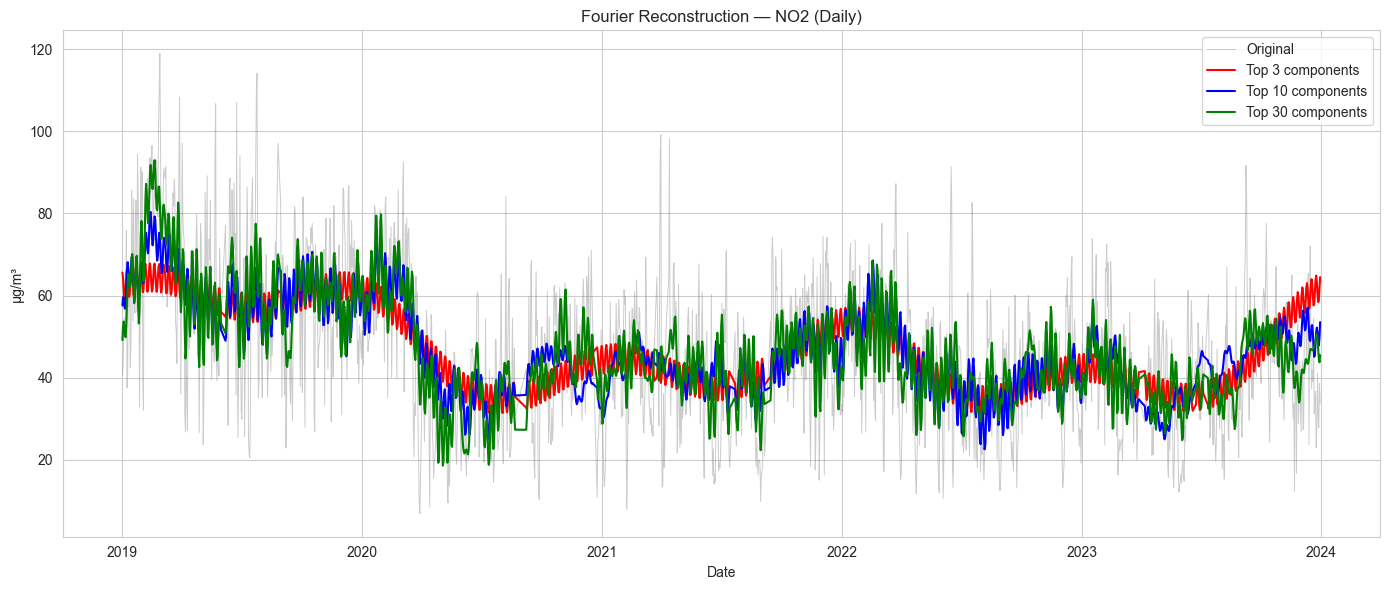

In [42]:
def fourier_reconstruct(series, n_components):
    """Reconstruct signal using top-n Fourier components."""
    N = len(series)
    y = series.values - series.mean()
    
    yf = fft(y)
    
    # Keep only top n_components (by amplitude)
    amplitudes = np.abs(yf)
    # Set everything except top components to zero
    threshold = np.sort(amplitudes)[::-1][2 * n_components]  # x2 for pos+neg freq
    yf_filtered = yf.copy()
    yf_filtered[amplitudes < threshold] = 0
    
    # Inverse FFT to reconstruct
    reconstructed = np.real(ifft(yf_filtered)) + series.mean()
    return reconstructed

# Reconstruct NO2 with different numbers of components
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily.index, daily["no2"], alpha=0.4, linewidth=0.7, label="Original", color="gray")

for n, color in zip([3, 10, 30], ["red", "blue", "green"]):
    recon = fourier_reconstruct(daily["no2"], n)
    ax.plot(daily.index, recon, linewidth=1.5, label=f"Top {n} components", color=color)

ax.set_title("Fourier Reconstruction — NO2 (Daily)")
ax.set_ylabel("µg/m³")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Save Cleaned Data for Modelling

Save the cleaned daily data back to SQLite so the next notebooks can use it directly.

In [43]:
conn = sqlite3.connect(DB_PATH)

# Save cleaned daily pollution (MY1)
merged.to_sql("clean_daily_my1", conn, if_exists="replace", index=True)
print(f"Saved 'clean_daily_my1' table: {merged.shape[0]} rows × {merged.shape[1]} cols")

# Verify
check = pd.read_sql("SELECT COUNT(*) as n FROM clean_daily_my1", conn)
print(f"Verified: {check['n'].values[0]} rows in DB")

conn.close()
print("\n✓ Notebook 01 complete — cleaned data ready for modelling!")

Saved 'clean_daily_my1' table: 1752 rows × 8 cols
Verified: 1752 rows in DB

✓ Notebook 01 complete — cleaned data ready for modelling!
